In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import string
import random
import cv2

In [3]:
train=pd.read_csv('archive/sign_mnist_test.csv')
test=pd.read_csv('archive/sign_mnist_test.csv')
train

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,6,149,149,150,150,150,151,151,150,151,...,138,148,127,89,82,96,106,112,120,107
1,5,126,128,131,132,133,134,135,135,136,...,47,104,194,183,186,184,184,184,182,180
2,10,85,88,92,96,105,123,135,143,147,...,68,166,242,227,230,227,226,225,224,222
3,0,203,205,207,206,207,209,210,209,210,...,154,248,247,248,253,236,230,240,253,255
4,3,188,191,193,195,199,201,202,203,203,...,26,40,64,48,29,46,49,46,46,53
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7167,1,135,119,108,102,105,99,61,103,121,...,108,112,116,114,118,180,184,176,167,163
7168,12,157,159,161,164,166,166,171,174,175,...,213,213,213,214,213,211,210,210,209,208
7169,2,190,191,190,191,190,190,192,192,191,...,216,215,213,214,214,213,210,211,209,208
7170,4,201,205,208,209,214,216,218,223,226,...,112,169,255,255,237,113,91,67,70,63


In [4]:
tungtungtung=tf.convert_to_tensor(train.drop('label',axis=1))
balerinacapuchina=tf.convert_to_tensor(test.drop('label',axis=1))
tungtungtung

<tf.Tensor: shape=(7172, 784), dtype=int64, numpy=
array([[149, 149, 150, ..., 112, 120, 107],
       [126, 128, 131, ..., 184, 182, 180],
       [ 85,  88,  92, ..., 225, 224, 222],
       ...,
       [190, 191, 190, ..., 211, 209, 208],
       [201, 205, 208, ...,  67,  70,  63],
       [173, 174, 173, ..., 195, 193, 192]], shape=(7172, 784))>

In [5]:
trainlabel= keras.utils.to_categorical(train['label'])
testlabel= keras.utils.to_categorical(test['label'])
trainlabel.shape

(7172, 25)

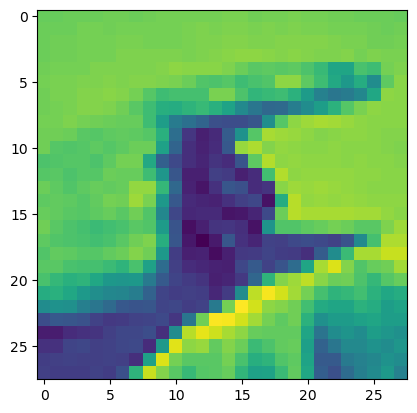

In [6]:
def show_img(ahihidongoc):
    ahihidongoc=tf.reshape(ahihidongoc,[-1,28,28])
    plt.imshow(ahihidongoc[0])
    plt.show()

show_img(tungtungtung)

In [7]:
minmax=MinMaxScaler()
tungtungtung=minmax.fit_transform(tungtungtung)
tungtungtung= tf.reshape(tungtungtung,[-1,28,28,1])
balerinacapuchina=minmax.fit_transform(balerinacapuchina)
balerinacapuchina= tf.reshape(balerinacapuchina,[-1,28,28,1])
tungtungtung

<tf.Tensor: shape=(7172, 28, 28, 1), dtype=float64, numpy=
array([[[[0.58431373],
         [0.58431373],
         [0.58823529],
         ...,
         [0.58823529],
         [0.58823529],
         [0.58431373]],

        [[0.58823529],
         [0.58823529],
         [0.58823529],
         ...,
         [0.59215686],
         [0.58823529],
         [0.59215686]],

        [[0.58823529],
         [0.59215686],
         [0.59215686],
         ...,
         [0.59215686],
         [0.59215686],
         [0.59607843]],

        ...,

        [[0.27058824],
         [0.27058824],
         [0.30196078],
         ...,
         [0.45490196],
         [0.44313725],
         [0.4627451 ]],

        [[0.29019608],
         [0.29411765],
         [0.29803922],
         ...,
         [0.43137255],
         [0.45490196],
         [0.44313725]],

        [[0.29411765],
         [0.29019608],
         [0.29019608],
         ...,
         [0.43921569],
         [0.47058824],
         [0.41960784]]],


 

In [8]:
X_train, X_val, y_train, y_val=train_test_split(tungtungtung.numpy(), trainlabel, test_size=0.33)
X_train=tf.convert_to_tensor(X_train)
X_val=tf.convert_to_tensor(X_val)

In [9]:
simplemodel=keras.Sequential([
    layers.InputLayer(shape=(28,28,1)),
    layers.Conv2D(64,kernel_size=(3,3), strides=(2,2),activation='relu'),
    layers.MaxPool2D(pool_size=3),
    layers.Conv2D(128,kernel_size=(5,5), strides=(1,1),padding='same',activation='relu'),
    layers.Conv2D(256,kernel_size=(5,5), strides=(1,1),padding='same',activation='relu'),
    layers.MaxPool2D(pool_size=3,strides=(2,2)),
    layers.Flatten(),
    layers.Dense(32,activation='relu')
])

input_layer=keras.Input(shape=(28,28,1))

ahaha=simplemodel(input_layer)

alphabelts= layers.Dense(25, activation='softmax', name='alphabelt')(ahaha)

box= layers.Dense(4, activation='sigmoid', name='box')(ahaha)

bbox_simplemodel= keras.Model(inputs=input_layer, outputs=[alphabelts, box])

In [10]:
def get_box(tensor):
    img = tensor.numpy()
    img = img.squeeze()
    #check normalized or not
    if img.max()<=1.0:
        img= (img * 255).astype('uint8')
    else:
        img =img.astype('uint8')
    _, thresh = cv2.threshold(img, 1, 255, cv2.THRESH_BINARY)
    x, y, w, h = cv2.boundingRect(thresh)
    return np.array([x/28, y/28, (x+w)/28, (y+h)/28], dtype='float32')

y_train_box= tf.convert_to_tensor([get_box(img) for img in X_train])
y_val_box= tf.convert_to_tensor([get_box(img) for img in X_val])
y_test_box=tf.convert_to_tensor([get_box(img) for img in balerinacapuchina])

bbox_simplemodel.summary()
bbox_simplemodel.compile(optimizer ='adam', loss ={'alphabelt':'categorical_crossentropy','box':keras.losses.Huber()}, 
                         metrics ={'alphabelt':'accuracy','box':'mae'})
bbox_simplemodel.fit(X_train, {'alphabelt':y_train,'box':y_train_box}, batch_size=64, 
                     epochs=5,validation_data=(X_val,{'alphabelt':y_val,'box':y_val_box}))

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 32)        │  1,033,248 │ input_layer_1[0]… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ alphabelt (Dense)   │ (None, 25)        │        825 │ sequential[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ box (Dense)         │ (None, 4)         │        132 │ sequential[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,034,205 (3.95 MB)

 Trainable params: 1,034,205 (3.95 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
76/76 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - alphabelt_accuracy: 0.0604 - alphabelt_loss: 3.1815 - box_loss: 0.0931 - box_mae: 0.4173 - loss: 3.2757 - val_alphabelt_accuracy: 0.0786 - val_alphabelt_loss: 3.1049 - val_box_loss: 0.0526 - val_box_mae: 0.2974 - val_loss: 3.1575
Epoch 2/5
76/76 ━━━━━━━━━━━━━━━━━━━━ 6s 77ms/step - alphabelt_accuracy: 0.2000 - alphabelt_loss: 2.7580 - box_loss: 0.0433 - box_mae: 0.2401 - loss: 2.8093 - val_alphabelt_accuracy: 0.3498 - val_alphabelt_loss: 2.2761 - val_box_loss: 0.0145 - val_box_mae: 0.1026 - val_loss: 2.2905
Epoch 3/5
76/76 ━━━━━━━━━━━━━━━━━━━━ 5s 67ms/step - alphabelt_accuracy: 0.4957 - alphabelt_loss: 1.7461 - box_loss: 0.0029 - box_mae: 0.0288 - loss: 1.7506 - val_alphabelt_accuracy: 0.6037 - val_alphabelt_loss: 1.3524 - val_box_loss: 8.9295e-05 - val_box_mae: 0.0029 - val_loss: 1.3524
Epoch 4/5
76/76 ━━━━━━━━━━━━━━━━━━━━ 6s 78ms/step - alphabelt_accuracy: 0.6897 - alphabelt_loss: 1.0020 - box_loss: 4.9131e-05 - box_mae: 0.0016 - los

In [11]:
predicted,box= bbox_simplemodel.predict(balerinacapuchina)
predicted=np.argmax(predicted, axis=1)
testlabel=np.argmax(testlabel, axis=1)

225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step


              precision    recall  f1-score   support

           A       0.83      0.94      0.88       331
           B       0.86      1.00      0.92       432
           C       1.00      0.85      0.92       310
           D       0.85      0.29      0.43       245
           E       0.92      0.98      0.95       498
           F       0.98      1.00      0.99       247
           G       0.92      0.67      0.77       348
           H       0.98      0.94      0.96       436
           I       0.94      1.00      0.97       288
           K       0.88      0.84      0.86       331
           L       0.90      1.00      0.95       209
           M       0.50      0.87      0.63       394
           N       0.55      0.52      0.54       291
           O       0.82      0.46      0.59       246
           P       0.86      0.97      0.91       347
           Q       1.00      0.62      0.77       164
           R       0.69      0.75      0.72       144
           S       0.93    

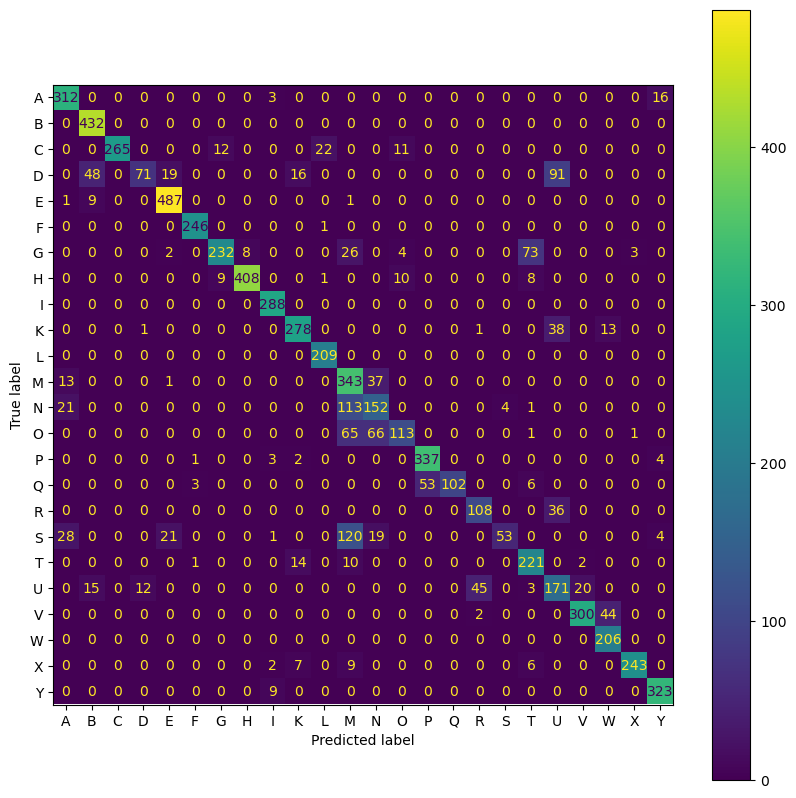

In [12]:
translation_table=str.maketrans("", "", "JZ")
alphabelt_list= list(string.ascii_uppercase.translate(translation_table))

print(classification_report(testlabel,predicted,target_names=alphabelt_list))
cm = confusion_matrix(testlabel, predicted)
cmp = ConfusionMatrixDisplay(cm, display_labels=alphabelt_list)
fig, ax = plt.subplots(figsize=(10,10))
cmp.plot(ax=ax)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


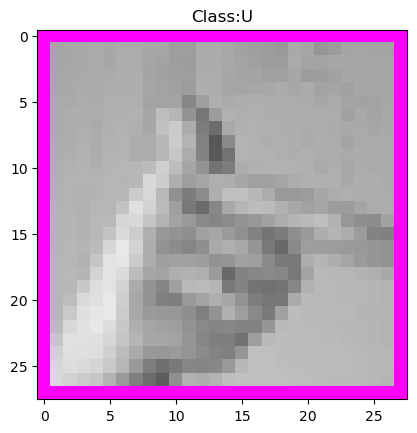

In [13]:
def show_randomresult_img(ahihidongoc,model):
    ahihidongoc=tf.reshape(ahihidongoc,[-1,28,28,1])
    Gojo_satoru=ahihidongoc[random.randint(0,len(ahihidongoc)-1)]
    Gojo_satoru=tf.expand_dims(Gojo_satoru, axis=0)
    pred,box=model.predict(Gojo_satoru)
    
    img=tf.squeeze(Gojo_satoru).numpy()
    img = img * 255
    img = img.astype(np.uint8)
    img=cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    
    x1, y1, x2, y2 = box[0]
    x1*= 28
    y1*= 28
    x2*= 28
    y2*= 28
    x1, y1, x2, y2 = int(x1),int(y1), int(x2), int(y2)
    x1= max(0, min(x1, 27))
    y1= max(0, min(y1, 27))
    x2= max(0, min(x2, 27))
    y2= max(0, min(y2, 27))
    
    cv2.rectangle(img, (x1,y1),(x2,y2), (255,0,255),1)
    pred=np.argmax(pred, axis=1)

    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(f'Class:{alphabelt_list[pred[0]]}')
    plt.show()

show_randomresult_img(balerinacapuchina,bbox_simplemodel)
# bbox_simplemodel.save('detect_hand_signs.h5')

In [14]:
Alexnet=keras.Sequential([
    layers.InputLayer(shape=(28,28,1)),
    layers.Resizing(224,224),
    layers.Conv2D(64,kernel_size=(11,11), strides=(2,2),padding='same',activation='relu'),
    layers.MaxPool2D(pool_size=3,strides=(2,2)),
    layers.Conv2D(128,kernel_size=(5,5), strides=(1,1),padding='same',activation='relu'),
    layers.MaxPool2D(pool_size=3,strides=(2,2)),
    layers.Conv2D(256,kernel_size=(3,3), strides=(1,1),padding='same',activation='relu'),
    layers.Conv2D(128,kernel_size=(3,3), strides=(1,1),padding='same',activation='relu'),
    layers.Conv2D(64,kernel_size=(3,3), strides=(1,1),padding='same',activation='relu'),
    layers.MaxPool2D(pool_size=3,strides=(2,2)),
    layers.Flatten(),
    layers.Dense(4096,activation='relu'),
    layers.Dropout(0.25),
    layers.Dense(4096,activation='relu'),
    layers.Dropout(0.25)
])

inputs=layers.Input(shape=(28,28,1))

ahaha=Alexnet(inputs)

alphabelt_complex= layers.Dense(25, activation='softmax',name='alphabelt_complex')(ahaha)

box_complex= layers.Dense(4, activation='sigmoid',name='box_complex')(ahaha)

bbox_alexnet_model= keras.Model(inputs=inputs, outputs=[alphabelt_complex, box_complex])

In [15]:
bbox_alexnet_model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_1        │ (None, 4096)      │ 61,964,480 │ input_layer_3[0]… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ alphabelt_complex   │ (None, 25)        │    102,425 │ sequential_1[0][… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ box_complex (Dense) │ (None, 4)         │     16,388 │ sequential_1[0][… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 62,083,293 (236.83 MB)

 Trainable params: 62,083,293 (236.83 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
bbox_alexnet_model.compile(optimizer ='adam', loss ={'alphabelt_complex':'categorical_crossentropy','box_complex':keras.losses.Huber()}, 
                         metrics ={'alphabelt_complex':'accuracy','box_complex':'mae'})
bbox_alexnet_model.fit(X_train, {'alphabelt_complex':y_train,'box_complex':y_train_box}, batch_size=64, 
                     epochs=5,validation_data=(X_val,{'alphabelt_complex':y_val,'box_complex':y_val_box}))

Epoch 1/5
76/76 ━━━━━━━━━━━━━━━━━━━━ 308s 4s/step - alphabelt_complex_accuracy: 0.0593 - alphabelt_complex_loss: 3.2540 - box_complex_loss: 0.0134 - box_complex_mae: 0.1186 - loss: 3.2682 - val_alphabelt_complex_accuracy: 0.0452 - val_alphabelt_complex_loss: 3.1478 - val_box_complex_loss: 0.0026 - val_box_complex_mae: 0.0726 - val_loss: 3.1505
Epoch 2/5
76/76 ━━━━━━━━━━━━━━━━━━━━ 306s 4s/step - alphabelt_complex_accuracy: 0.0585 - alphabelt_complex_loss: 3.1561 - box_complex_loss: 0.0014 - box_complex_mae: 0.0488 - loss: 3.1548 - val_alphabelt_complex_accuracy: 0.0739 - val_alphabelt_complex_loss: 3.1384 - val_box_complex_loss: 8.3018e-04 - val_box_complex_mae: 0.0407 - val_loss: 3.1392
Epoch 3/5
32/76 ━━━━━━━━━━━━━━━━━━━━ 3:40 5s/step - alphabelt_complex_accuracy: 0.0644 - alphabelt_complex_loss: 3.1455 - box_complex_loss: 0.0012 - box_complex_mae: 0.0484 - loss: 3.1467

KeyboardInterrupt: 

In [ ]:
predicted= bbox_alexnet_model.predict(balerinacapuchina)
predicted=np.argmax(predicted, axis=1)

In [ ]:
print(classification_report(testlabel,predicted,target_names=alphabelt))
cm = confusion_matrix(testlabel, predicted)
cmp = ConfusionMatrixDisplay(cm, display_labels=alphabelt)
fig, ax = plt.subplots(figsize=(10,10))
cmp.plot(ax=ax)

In [ ]:
show_randomresult_img(balerinacapuchina,bbox_alexnet_model)
bbox_alexnet_model.save('detect_hand_signs_alexnet.h5')